# Spectral fitting example (GRB)

**To run this, you need the following files, which can be downloaded using the first few cells of this notebook:**
- orientation file (20280301_3_month_with_orbital_info.fits)       
- binned data (grb_bkg_binned_data.hdf5, grb_binned_data.hdf5, & bkg_binned_data_1s_local.hdf5)     
- detector response (SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5)     

**The binned data are simulations of GRB090206620 and albedo photon background produced using the COSI SMEX mass model. The detector response needs to be unzipped before running the notebook.**

This notebook fits the spectrum of a GRB simulated using MEGAlib and combined with background.

[3ML](https://threeml.readthedocs.io/) is a high-level interface that allows multiple datasets from different instruments to be used coherently to fit the parameters of source model. A source model typically consists of a list of sources with parametrized spectral shapes, sky locations and, for extended sources, shape. Polarization is also possible. A "coherent" analysis, in this context, means that the source model parameters are fitted using all available datasets simultanously, rather than performing individual fits and finding a well-suited common model a posteriori. 

In order for a dataset to be included in 3ML, each instrument needs to provide a "plugin". Each plugin is responsible for reading the data, convolving the source model (provided by 3ML) with the instrument response, and returning a likelihood. In our case, we'll compute a binned Poisson likelihood:

$$
\log \mathcal{L}(\mathbf{x}) = \sum_i \log \frac{\lambda_i(\mathbf{x})^{d_i} \exp (-\lambda_i)}{d_i!}
$$

where $d_i$ are the counts on each bin and $\lambda_i$ are the expected counts given a source model with parameters $\mathbf{x}$. 

In this example, we will fit a single point source with a known location. We'll assume the background is known and fixed up to a scaling factor. Finally, we will fit a Band function:

$$
f(x) = K \begin{cases} \left(\frac{x}{E_{piv}}\right)^{\alpha} \exp \left(-\frac{(2+\alpha)
       * x}{x_{p}}\right) & x \leq (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \\ \left(\frac{x}{E_{piv}}\right)^{\beta}
       * \exp (\beta-\alpha)\left[\frac{(\alpha-\beta) x_{p}}{E_{piv}(2+\alpha)}\right]^{\alpha-\beta}
       * &x>(\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases}
$$


where $K$ (normalization), $\alpha$ & $\beta$ (spectral indeces), and $x_p$ (peak energy) are the free parameters, while $E_{piv}$ is the pivot energy which is fixed (and arbitrary).

Considering these assumptions:

$$
\lambda_i(\mathbf{x}) = B*b_i + s_i(\mathbf{x})
$$

where $B*b_i$ are the estimated counts due to background in each bin of the Compton data space with $B$ the amplitude and $b_i$ the shape of the background, and $s_i$ are the corresponding expected counts from the source, the goal is then to find the values of $\mathbf{x} = [K, \alpha, \beta, x_p]$ and $B$ that maximize $\mathcal{L}$. These are the best estimations of the parameters.

The final module needs to also fit the time-dependent background, handle multiple point-like and extended sources, as well as all the spectral models supported by 3ML. Eventually, it will also fit the polarization angle. However, this simple example already contains all the necessary pieces to do a fit.

In [1]:
%%capture
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time
from astropy.stats import poisson_conf_interval

from astromodels import Model, Parameter, PointSource, Band
from threeML import JointLikelihood, DataList
    
from cosipy import COSILike, BinnedData
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.util import fetch_wasabi_file

%matplotlib inline

## Download and read in binned data

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into

In [2]:
data_path = Path("") # /path/to/files. Current dir by default

Download the orientation file (684.38 MB)

In [3]:
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/20280301_3_month_with_orbital_info.fits', output = data_path / '20280301_3_month_with_orbital_info.fits', checksum = 'bf59c4b79bc95ab68bcd376357f7bd40')

A file named 20280301_3_month_with_orbital_info.fits already exists with the specified checksum (bf59c4b79bc95ab68bcd376357f7bd40). Skipping.


Download the binned GRB+background data (75.73 KB)

In [4]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/grb_spectral_fit_local_frame/grb_bkg_binned_data.hdf5', output = data_path / 'grb_bkg_binned_data.hdf5', checksum = 'fce391a4b45624b25552c7d111945f60')

A file named grb_bkg_binned_data.hdf5 already exists with the specified checksum (fce391a4b45624b25552c7d111945f60). Skipping.


Download the binned GRB data (76.90 KB)

In [5]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/grb_spectral_fit_local_frame/grb_binned_data.hdf5', output = data_path / 'grb_binned_data.hdf5', checksum = 'fcf7022369b6fb378d67b780fc4b5db8')

A file named grb_binned_data.hdf5 already exists with the specified checksum (fcf7022369b6fb378d67b780fc4b5db8). Skipping.


Download the binned background data (255.97 MB)

In [6]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/grb_spectral_fit_local_frame/bkg_binned_data_1s_local.hdf5', output = data_path / 'bkg_binned_data_1s_local.hdf5', checksum = 'b842a7444e6fc1a5dd567b395c36ae7f')

A file named bkg_binned_data_1s_local.hdf5 already exists with the specified checksum (b842a7444e6fc1a5dd567b395c36ae7f). Skipping.


Download the response file (596.06 MB)

In [7]:
fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5', output= data_path / 'SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5', checksum = 'eb72400a1279325e9404110f909c7785')

A file named SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5 already exists with the specified checksum (eb72400a1279325e9404110f909c7785). Skipping.


Read in the spacecraft orientation file & select the beginning and end times of the GRB

In [8]:
ori = SpacecraftFile.open(data_path / "20280301_3_month_with_orbital_info.fits")
tmin = Time(1842597410.0,format = 'unix')
tmax = Time(1842597450.0,format = 'unix')
sc_orientation = ori.source_interval(tmin, tmax)

Create BinnedData objects for the GRB only, GRB+background, and background only. The GRB only simulation is not used for the spectral fit, but can be used to compare the fitted spectrum to the source simulation

In [9]:
grb = BinnedData(data_path / "grb.yaml")
grb_bkg = BinnedData(data_path / "grb.yaml")
bkg = BinnedData(data_path / "background.yaml")

Load binned .hdf5 files

In [10]:
grb.load_binned_data_from_hdf5(binned_data=data_path / "grb_binned_data.hdf5")
grb_bkg.load_binned_data_from_hdf5(binned_data=data_path / "grb_bkg_binned_data.hdf5")
bkg.load_binned_data_from_hdf5(binned_data=data_path / "bkg_binned_data_1s_local.hdf5")

Define the path to the detector response

In [11]:
dr = data_path / "SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5" # path to detector response

## Perform spectral fit

Define time window of binned background simulation to use for background model

In [12]:
bkg_tmin = 1842597310.0
bkg_tmax = 1842597550.0

bkg_min, bkg_max = np.searchsorted(bkg.binned_data.axes['Time'].edges.value,
                                   (bkg_tmin, bkg_tmax), side='left')

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [13]:
%%time

bkg_par = Parameter("background_cosi",                                                                          # background parameter
                    0.1,                                                                                        # initial value of parameter
                    min_value=0,                                                                                # minimum value of parameter
                    max_value=5,                                                                                # maximum value of parameter
                    delta=1e-3,                                                                                 # initial step used by fitting engine
                    desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                                                         # COSI 3ML plugin
                dr = dr,                                                                                        # detector response
                data = grb_bkg.binned_data.project('Em', 'Phi', 'PsiChi'),                                      # data (source+background)
                bkg = bkg.binned_data.slice[{'Time':slice(bkg_min,bkg_max)}].project('Em', 'Phi', 'PsiChi'),    # background model 
                sc_orientation = sc_orientation,                                                                # spacecraft orientation
                nuisance_param = bkg_par)                                                                       # background parameter

CPU times: user 2.97 s, sys: 29.6 ms, total: 3 s
Wall time: 3.01 s


Define a point source at the known location with a Band function spectrum and add it to the model

In [14]:
l = 93.
b = -53.

alpha = -1                                       # Setting parameters to something reasonable helps the fitting to converge\n",
beta = -3
xp = 450. * u.keV
piv = 500. * u.keV
K = 1 / u.cm / u.cm / u.s / u.keV

spectrum = Band()

spectrum.beta.min_value = -15.0

spectrum.alpha.value = alpha
spectrum.beta.value = beta
spectrum.xp.value = xp.value
spectrum.K.value = K.value
spectrum.piv.value = piv.value

spectrum.xp.unit = xp.unit
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# Optional: free the position parameters
#source.position.l.free = True
#source.position.b.free = True

model = Model(source)                              # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# Optional: if you want to call get_log_like manually, then you also need to set the model manually
# 3ML does this internally during the fit though
cosi.set_model(model)

Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [15]:
%%time

plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit(quiet=True);

09:25:36 INFO      set the minimizer to minuit                                              ]8;id=345404;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=987771;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#994\994]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


09:25:57 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=813360;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=52803;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/plugin_prototype.py#119\119]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

CPU times: user 8min 26s, sys: 1.43 s, total: 8min 28s
Wall time: 21.5 s


## Error propagation and plotting

Define Band function spectrum injected into MEGAlib

In [16]:
alpha_inj = -0.360
beta_inj = -11.921
E0_inj = 288.016 * u.keV
xp_inj = E0_inj * (alpha_inj + 2)
piv_inj = 1. * u.keV
K_inj = 0.283 / u.cm / u.cm / u.s / u.keV

spectrum_inj = Band()

spectrum_inj.beta.min_value = -15.0

spectrum_inj.alpha.value = alpha_inj
spectrum_inj.beta.value = beta_inj
spectrum_inj.xp.value = xp_inj.value
spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value

spectrum_inj.xp.unit = xp_inj.unit
spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit

The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [17]:
results = like.results

results.display()

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(3.10 -0.20 +0.21) x 10^-2,1 / (keV s cm2)
source.spectrum.main.Band.alpha,(-2.8 +/- 0.5) x 10^-1,
source.spectrum.main.Band.xp,(4.75 +/- 0.05) x 10^2,keV
source.spectrum.main.Band.beta,-6.8 +/- 1.2,
background_cosi,(1.65 +/- 0.13) x 10^-1,


Correlation matrix:

1.00,0.97,-0.37,0.20,-0.00
0.97,1.00,-0.16,0.18,-0.00
-0.37,-0.16,1.00,-0.17,-0.02
0.20,0.18,-0.17,1.00,0.00
-0.00,-0.00,-0.02,0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,42920.049348
total,42920.049348


Values of statistical measures:

,statistical measures
AIC,85838.098697
BIC,85840.098697


  * source (point source):
    * position:
      * l:
        * value: 93.0
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -53.0
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Band:
          * K:
            * value: 0.030989945313827722
            * desc: Differential flux at the pivot energy
            * min_value: 1.0e-50
            * max_value: null
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * alpha:
            * value: -0.27672651241717205
            * desc: low-energy photon index
            * min_value: -1.5
            * max_value: 3.0
            * unit: ''
            * is_normalization: false
          * xp:
            * value: 474.6541226231709
         

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [18]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = grb.binned_data.axes['Em'].edges.value
binned_energy = grb.binned_data.axes['Em'].centers.value

expectation = cosi._expected_counts['source']

Plot the fitted and injected spectra

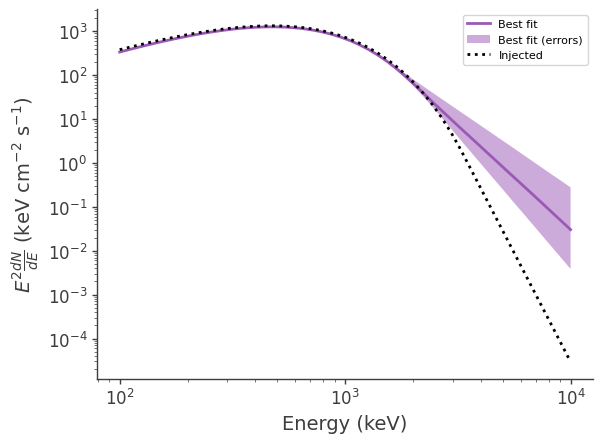

In [19]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend();

In [20]:
def compute_errors(counts):
    gaussian_error = np.zeros(len(counts))
    poisson_error  = np.zeros((2, len(counts)))

    hi_mask = (counts > 5)
    gaussian_error[hi_mask] = np.sqrt(counts[hi_mask])
    poisson_error[:,~hi_mask] = poisson_conf_interval(counts[~hi_mask], interval="frequentist-confidence", sigma=1)

    return gaussian_error, poisson_error

Plot the fitted spectrum convolved with the response, as well as the simulated source counts

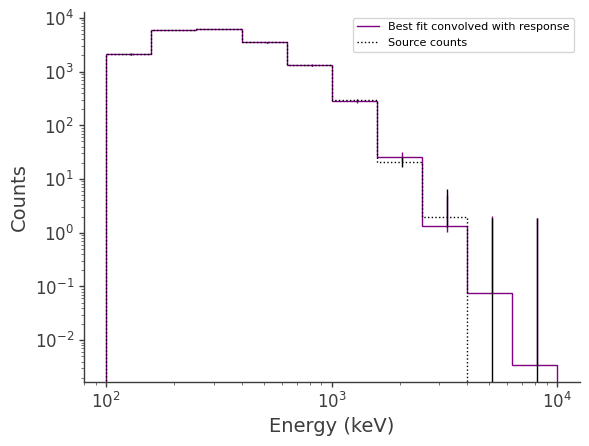

In [21]:
em_inj = grb.binned_data.project('Em').todense().contents
em_fit = expectation.project('Em').todense().contents

fit_gaussian_error, fit_poisson_error = compute_errors(em_fit)
inj_gaussian_error, inj_poisson_error = compute_errors(em_inj)

fig,ax = plt.subplots()

ax.stairs(em_fit, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, em_fit, yerr=fit_poisson_error, color='purple', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, em_fit, yerr=fit_gaussian_error, color='purple', linewidth=0, elinewidth=1)
ax.stairs(em_inj, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, em_inj, yerr=inj_poisson_error, color='black', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, em_inj, yerr=inj_gaussian_error, color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend();

Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts

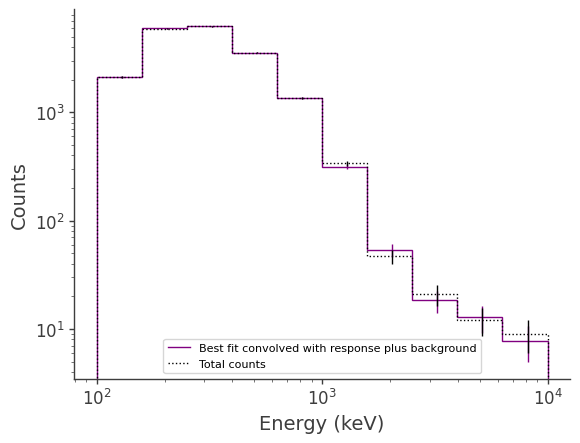

In [22]:
em_inj_bkg = grb_bkg.binned_data.project('Em').todense().contents
em_fit_bkg = bkg_par.value * bkg.binned_data.slice[{'Time':slice(bkg_min,bkg_max)}].project('Em').todense().contents
em_fit_total = em_fit + em_fit_bkg

fit_bkg_gaussian_error, fit_bkg_poisson_error = compute_errors(em_fit_total)
inj_bkg_gaussian_error, inj_bkg_poisson_error = compute_errors(em_inj_bkg)

fig,ax = plt.subplots()

ax.stairs(em_fit_total, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, em_fit_total, yerr=fit_bkg_poisson_error, color='purple', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, em_fit_total, yerr=fit_bkg_gaussian_error, color='purple', linewidth=0, elinewidth=1)
ax.stairs(em_inj_bkg, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, em_inj_bkg, yerr=inj_bkg_poisson_error, color='black', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, em_inj_bkg, yerr=inj_bkg_gaussian_error, color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend();